# Compare Loop 3 and Loop 2.5 on Monocyte Enrichment.

## Prepare the Notebook.

### Import the Libraries.

In [1]:
import joblib
import os
import sys
import yaml

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist
from scipy.stats import gaussian_kde
import seaborn as sns
from tqdm import tqdm

### Read Annotation Configurations from Loop 2.5.

In [2]:
config2_path = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/inverse/loss_guidance/config/annotation/bloodplus.yaml"
with open(config2_path, "r") as fb:
    annot2_dict = yaml.safe_load(fb)
protocol_cols2 = annot2_dict["protocol_columns"]
resc_protocol_cols2 = [f"{c}:rescaled" for c in protocol_cols2]

### Read Annotation Configurations from Loop 3.

In [3]:
config3_path = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/inverse/loss_guidance/config/annotation/bloodplus_loop3.yaml"
with open(config3_path, "r") as fb:
    annot3_dict = yaml.safe_load(fb)
protocol_cols3 = annot3_dict["protocol_columns"]
resc_protocol_cols3 = [f"{c}:rescaled" for c in protocol_cols3]

### Get Additional Molecules from Loop 3.

In [19]:
additional_molecules = list(set(protocol_cols3).difference(set(protocol_cols2)))
additional_molecules

['il7_[ng_ml]', 'ly_cocktail_[ul/well]', 'mcsf_[ng_ml]']

### Read Constraints Configurations from Loop 3.

In [4]:
constraints3_config_path = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/inverse/loss_guidance/config/constraints/default_all_cols_loop3.yaml"
with open(constraints3_config_path, "r") as fb:
    constraints3_config = yaml.safe_load(fb)
ubound3_dict = constraints3_config["ubound_dict"]
lbound3_dict = constraints3_config["lbound_dict"]


## Read Optimization Results.

### Define Function to Read Results Directory in a Parallelized Way.

In [12]:
def get_masked_opt_df(
    res_base_dir
):
    all_runs = []

    opt_modes_list = os.listdir(res_base_dir)

    for opt_leaf_dir in opt_modes_list:
        opt_dir = os.path.join(res_base_dir, opt_leaf_dir)
        cts_list = os.listdir(opt_dir)

        for ct_leaf_dir in cts_list:
            ct_dir = os.path.join(opt_dir, ct_leaf_dir)
            runs_list = os.listdir(ct_dir)

            for run_leaf_dir in runs_list:
                run_dir = os.path.join(ct_dir, run_leaf_dir)
                csv_path = os.path.join(run_dir, "candidates.csv")

                masked_eval_dir = os.path.join(run_dir, "masked_eval")
                masked_csv_path = os.path.join(masked_eval_dir, "masked_ct_props.csv")

                if not os.path.isfile(masked_csv_path):
                    continue

                all_runs.append(
                    {
                        "target_ct": ct_leaf_dir,
                        "run_id": run_leaf_dir,
                        "opt_id": opt_leaf_dir,
                        "csv_path": csv_path,
                        "masked_csv_path": masked_csv_path,
                    }
                )

    def _load_run(run_dict):
        target_ct = run_dict["target_ct"]
        run_id = run_dict["run_id"]
        opt_id = run_dict["opt_id"]
        csv_path = run_dict["csv_path"]
        masked_csv_path = run_dict["masked_csv_path"]

        df = pd.read_csv(csv_path)
        df["run_id"] = run_id
        df["opt_id"] = opt_id
        df["target_ct"] = target_ct

        df_masked = pd.read_csv(masked_csv_path)
        df_masked = df_masked.add_suffix(":masked")

        # Column‑wise concatenation (assumes rows are aligned)
        merged = pd.concat([df, df_masked], axis=1)
        return merged
        
    n_jobs = 100
    data = joblib.Parallel(n_jobs=n_jobs)(joblib.delayed(_load_run)(run_dict) for run_dict in all_runs)
    return pd.concat(data, ignore_index=True)

### Read Optimization Data from Looop 3.

In [13]:
res_base_dir3 = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/inverse/loss_guidance/loop3_replicate"
opt_df3 = get_masked_opt_df(res_base_dir3)
opt_df3

,sample_id,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],...,MPP_MgkEry_prop:masked,MgKEryPro1_prop:masked,MgKEryPro2_prop:masked,ProB_prop:masked,earlyMPP_prop:masked,late_MgkPro_prop:masked,preProB_prop:masked,pre_cDC1_prop:masked,pre_cDC2_prop:masked,sample_id:masked
0,CD14Mono:2026-06-27_09-53-20_df4a4317:0,10.116483,1.913542,783.94910,0.000000,1.658651,36.975235,0.000000,0.000627,0.000000,...,0.062957,0.011225,0.000001,0.000604,0.002966,0.002114,0.005941,0.000706,0.006034,CD14Mono:2026-06-27_09-53-20_df4a4317:0
1,CD14Mono:2026-06-27_09-53-20_df4a4317:1,10.047714,1.276843,749.97205,1127.488600,0.287596,4.977289,0.050081,0.702524,0.000000,...,0.108905,0.028342,0.000217,0.000568,0.002927,0.000119,0.002229,0.000817,0.047837,CD14Mono:2026-06-27_09-53-20_df4a4317:1
2,CD14Mono:2026-06-27_09-53-20_df4a4317:2,10.506727,2.642519,816.32210,0.000000,1.104251,54.857925,0.519109,0.001524,0.000000,...,0.014551,0.079849,0.002053,0.000859,0.001994,0.002733,0.003279,0.000753,0.001504,CD14Mono:2026-06-27_09-53-20_df4a4317:2
3,CD14Mono:2026-06-27_09-53-20_df4a4317:3,9.973374,1.549195,298.13467,1128.622400,0.600947,49.880455,0.043198,0.169792,0.000000,...,0.136075,0.042031,0.000653,0.000456,0.003504,0.000017,0.004634,0.000731,0.006884,CD14Mono:2026-06-27_09-53-20_df4a4317:3
4,CD14Mono:2026-06-27_09-53-20_df4a4317:4,9.234617,2.684378,749.90900,908.116600,0.000000,51.506702,0.601246,0.000037,0.548479,...,0.003892,0.176490,0.013067,0.000149,0.006796,0.000508,0.004018,0.002950,0.031722,CD14Mono:2026-06-27_09-53-20_df4a4317:4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3845,CD14Mono:2026-06-26_21-21-22_87cd7ac3:45,10.092893,2.449771,757.85460,939.064700,0.000000,49.510086,0.000000,0.000000,1.028420,...,0.004030,0.224018,0.035113,0.000071,0.005210,0.000518,0.001490,0.000089,0.008279,NaN
3846,CD14Mono:2026-06-26_21-21-22_87cd7ac3:46,9.596495,2.589260,505.43840,0.325946,0.811287,1.908527,0.072123,0.000000,0.140598,...,0.029634,0.062784,0.000770,0.000354,0.001535,0.015875,0.002218,0.005217,0.005095,NaN
3847,CD14Mono:2026-06-26_21-21-22_87cd7ac3:47,10.295144,2.071969,587.23035,681.848000,0.191236,21.656097,0.062192,0.000000,0.000000,...,0.019732,0.119842,0.013592,0.000093,0.003522,0.000027,0.004582,0.000195,0.006462,NaN
3848,CD14Mono:2026-06-26_21-21-22_87cd7ac3:48,9.852677,1.912721,636.27820,0.000000,1.585846,49.586216,0.009235,0.000000,0.000000,...,0.139803,0.064443,0.003144,0.000605,0.004837,0.000044,0.004559,0.001819,0.004865,NaN


## Filter Optimization Data on Experimental Constraints.

### Define Function to Filter Optimization Data Based on Experimental Constraints.

In [14]:
def filter_opt_results(candidates_df, lbound_dict, ubound_dict,  margin = 0.1):
    # ----  Target Markers Loop ----
    print("---- Filtering Results ----")
    # define mask for all columns
    marker_mask = np.full(candidates_df.shape[0], True)

    # ----  Protocol Columns Loop ----
    for col, col_ubound in ubound_dict.items():
        # get col bounds
        col_lbound = lbound_dict[col]
        print(f"\t\t---- Processing Column {col} -> U: {col_ubound}, L: {col_lbound} ----")

        # get col values and mask
        col_values = candidates_df[col]
        col_mask_ubound_mask = col_values <= col_ubound*(1 + margin)
        col_mask_lbound_mask = col_values >= col_lbound*(1 - margin)

        # get masks for current column
        old_mask = marker_mask
        lbound_marker_mask = marker_mask & col_mask_lbound_mask
        ubound_marker_mask = marker_mask & col_mask_ubound_mask
        marker_mask = marker_mask & col_mask_ubound_mask & col_mask_lbound_mask

        # get number of solutions
        n_previously_accepted_solutions = old_mask.sum()
        n_accepted_solutions = marker_mask.sum()
        n_solutions_passing_ubound = col_mask_ubound_mask.sum()
        n_solutions_passing_lbound = col_mask_lbound_mask.sum()
        n_solutions_passing_ubound_and_previous_constraints = ubound_marker_mask.sum()
        n_solutions_passing_lbound_and_previous_constraints = lbound_marker_mask.sum()
        print(f"\t\t\t --- Number Previously Accepted Solutions {n_previously_accepted_solutions} ---")
        print(f"\t\t\t --- Number Currently Accepted Solutions {n_accepted_solutions} ---")
        print(f"\t\t\t --- Number of Solution Satisfying Upper Bound {n_solutions_passing_ubound} ---")
        print(f"\t\t\t --- Number of Solution Satisfying Lower Bound {n_solutions_passing_lbound} ---")
        print(f"\t\t\t --- Number of Solution Satisfying Upper Bound and Previous Constraints {n_solutions_passing_ubound_and_previous_constraints} ---")
        print(f"\t\t\t --- Number of Solution Satisfying Lower Bound and Previous Constraints {n_solutions_passing_lbound_and_previous_constraints} ---")


        # write values for constraint on current column
        candidates_df[f"passes_constraints:{col}:ubound"] = col_mask_ubound_mask
        candidates_df[f"passes_constraints:{col}:lbound"] = col_mask_ubound_mask

    # write values for all constraints
    n_all_solutions = candidates_df.shape[0]
    n_accepted_solutions = marker_mask.sum()
    candidates_df["passes_constraints:all"] = marker_mask

    print(f"\t\t\t--- Finished, Out of {n_all_solutions} there are {n_accepted_solutions} Passing with Margin {margin} ----")
    return candidates_df

### Filter Optimization Data from Loop 3.

In [15]:
opt_df3 = filter_opt_results(opt_df3, lbound3_dict, ubound3_dict)
opt_df3_filt = opt_df3[opt_df3["passes_constraints:all"]]
opt_df3_filt.shape[0] / opt_df3.shape[0]

---- Filtering Results ----
		---- Processing Column gm-csf_[ng_ml] -> U: 10.0, L: 0.0 ----
			 --- Number Previously Accepted Solutions 3850 ---
			 --- Number Currently Accepted Solutions 3848 ---
			 --- Number of Solution Satisfying Upper Bound 3848 ---
			 --- Number of Solution Satisfying Lower Bound 3850 ---
			 --- Number of Solution Satisfying Upper Bound and Previous Constraints 3848 ---
			 --- Number of Solution Satisfying Lower Bound and Previous Constraints 3850 ---
		---- Processing Column tpo_[ng_ml] -> U: 2.5, L: 0.0 ----
			 --- Number Previously Accepted Solutions 3848 ---
			 --- Number Currently Accepted Solutions 3816 ---
			 --- Number of Solution Satisfying Upper Bound 3818 ---
			 --- Number of Solution Satisfying Lower Bound 3850 ---
			 --- Number of Solution Satisfying Upper Bound and Previous Constraints 3816 ---
			 --- Number of Solution Satisfying Lower Bound and Previous Constraints 3848 ---
		---- Processing Column um171_[nm] -> U: 1120.0, L: 0.0 ----


0.9563636363636364

### Construct Data Frame.

In [ ]:
target_ct_values = opt_df3_filt.target_ct.unique()

all_records = []
for ct in target_ct_values:
    ct_col = f"{ct}_prop"
    ct_col_masked = f"{ct}_prop:masked"

    ct_probs = opt_df3_filt[ct_col].values
    ct_probs_masked = opt_df3_filt[ct_col_masked].values
    delta_ct_prob = ct_probs - ct_probs_masked

    mol_values = {mol:opt_df3_filt[mol].values for mol in additional_molecules}

    for idx in range(ct_probs.shape[0]):
        all_records.append(
            {
                f"Target Cell Type": ct,
                f"{ct}% Original": ct_probs[idx],
                f"{ct}% Masked": ct_probs_masked[idx],
                f"Delta {ct}%": delta_ct_prob[idx],
                **{mol:val[idx] for mol, val in mol_values.items()}
            }
        )

masked_eval_df = pd.DataFrame(all_records)
masked_eval_df

,Target Cell Type,CD14Mono% Original,CD14Mono% Masked,Delta CD14Mono%,il7_[ng_ml],ly_cocktail_[ul/well],mcsf_[ng_ml]
0,CD14Mono,0.080137,0.023487,0.056650,0.000000,0.121762,0.581246
1,CD14Mono,0.000135,0.001957,-0.001822,0.000000,0.000000,0.000000
2,CD14Mono,0.253678,0.017549,0.236130,0.000000,0.000000,13.879835
3,CD14Mono,0.007393,0.004107,0.003286,0.000000,0.000000,0.000221
4,CD14Mono,0.000110,0.001344,-0.001233,0.011118,0.000000,1.034389
...,...,...,...,...,...,...,...
3677,CD14Mono,0.003219,0.005416,-0.002197,0.000000,0.000000,0.000000
3678,CD14Mono,0.000360,0.003555,-0.003196,0.000000,0.000000,0.000000
3679,CD14Mono,0.018276,0.017227,0.001049,0.000000,0.000000,0.000000
3680,CD14Mono,0.011341,0.003140,0.008201,0.000000,0.000000,0.000000


### Plot Reduction.

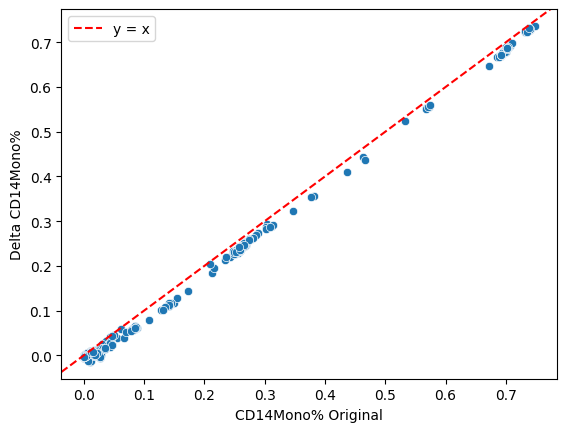

In [24]:
sns.scatterplot(
    masked_eval_df, x="CD14Mono% Original", y="Delta CD14Mono%"
)
# Add the y = x line (slope=1, intercept=0)
plt.axline((0, 0), slope=1, color='red', linestyle='--', label='y = x')
plt.legend()  # optional: show the label
plt.show()